In [1]:
import os
import glob
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Find all CSV files in the current folder
csv_files = glob.glob("*.csv")

if not csv_files:
    raise FileNotFoundError(
        "No CSV file found. Put the dataset inside the ExpenseModel folder."
    )

csv_path = csv_files[0]

print("Dataset found:", csv_path)

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset found: expense_data.csv
Dataset loaded successfully.
Dataset shape: (35000, 25)


,UserID,Year,Month,Age,Occupation,FamilySize,CityType,MonthlyIncome,Rent,Groceries,...,Shopping,SubscriptionCount,SubscriptionCost,EMI_Loan,Investment,Savings,PreviousMonthExpense,FestivalMonth,TotalExpense,NextMonthExpense
0,U0001,2020,February,35,Teacher,3,Urban,74318.22,13573.22,32337.26,...,10900.52,4,4272,4598.38,4459.09,-26672.50,109115.24,0,100990.72,111064.97
1,U0001,2020,March,35,Teacher,3,Urban,74753.15,14730.92,24738.25,...,11374.63,4,8040,8201.10,4485.19,-36311.82,100990.72,0,111064.97,119542.05
2,U0001,2020,April,35,Teacher,3,Urban,75243.88,18292.14,37352.87,...,8717.94,4,5684,12109.87,4514.63,-44298.18,111064.97,1,119542.05,115892.92
3,U0001,2020,May,35,Teacher,3,Urban,75293.65,17493.10,39924.16,...,9652.54,4,9724,4511.75,4517.62,-40599.27,119542.05,0,115892.92,107052.08
4,U0001,2020,June,35,Teacher,3,Urban,75340.94,16376.44,32646.45,...,6032.24,4,8220,3962.64,4520.46,-31711.15,115892.92,0,107052.08,115202.11


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['UserID', 'Year', 'Month', 'Age', 'Occupation', 'FamilySize', 'CityType', 'MonthlyIncome', 'Rent', 'Groceries', 'Transportation', 'Utilities', 'Healthcare', 'Education', 'Entertainment', 'Shopping', 'SubscriptionCount', 'SubscriptionCost', 'EMI_Loan', 'Investment', 'Savings', 'PreviousMonthExpense', 'FestivalMonth', 'TotalExpense', 'NextMonthExpense']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                35000 non-null  object 
 1   Year                  35000 non-null  int64  
 2   Month                 35000 non-null  object 
 3   Age                   35000 non-null  int64  
 4   Occupation            35000 non-null  object 
 5   FamilySize            35000 non-null  int64  
 6   CityType              35000 non-null  object 
 7   MonthlyIncome         35000 non-null

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UserID,35000,500,U0500,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,35000.0,NaN,NaN,NaN,2022.5,1.679735,2020.0,2021.0,2022.5,2024.0,2025.0
Month,35000,12,February,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,35000.0,NaN,NaN,NaN,40.026,12.454146,18.0,28.75,41.0,51.0,60.0
Occupation,35000,8,Government Employee,5600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FamilySize,35000.0,NaN,NaN,NaN,3.636,1.462725,1.0,2.0,4.0,5.0,6.0
CityType,35000,3,Rural,12600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyIncome,35000.0,NaN,NaN,NaN,287901.568502,197205.793124,30720.89,127962.6875,241682.48,401718.245,1081780.95
Rent,35000.0,NaN,NaN,NaN,66261.60743,46514.067124,5677.13,29101.945,54775.71,92532.785,284185.39
Groceries,35000.0,NaN,NaN,NaN,44982.830591,20145.723397,8013.1,28656.86,43363.19,59286.1875,103499.26


In [5]:
print("NextMonthExpense statistics:")
print(df["NextMonthExpense"].describe())

NextMonthExpense statistics:
count     35000.000000
mean     234778.165794
std       99858.556612
min       55322.360000
25%      160080.630000
50%      213311.075000
75%      290419.557500
max      805906.470000
Name: NextMonthExpense, dtype: float64


In [6]:
categorical_columns_to_check = [
    "UserID",
    "Month",
    "Occupation",
    "CityType"
]

for column in categorical_columns_to_check:
    print(f"\nColumn: {column}")
    print("Unique values:", df[column].nunique())

    if column != "UserID":
        print(df[column].value_counts())


Column: UserID
Unique values: 500

Column: Month
Unique values: 12
Month
February     3000
March        3000
April        3000
May          3000
June         3000
July         3000
August       3000
September    3000
October      3000
November     3000
December     2500
January      2500
Name: count, dtype: int64

Column: Occupation
Unique values: 8
Occupation
Government Employee    5600
Business Owner         5250
Teacher                4410
Doctor                 4340
Engineer               4200
Manager                3990
Freelancer             3640
Student                3570
Name: count, dtype: int64

Column: CityType
Unique values: 3
CityType
Rural       12600
Suburban    11410
Urban       10990
Name: count, dtype: int64


In [7]:
# Create a copy before preprocessing
data = df.copy()

# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()

# Remove leading/trailing spaces from text columns
text_columns = data.select_dtypes(include="object").columns

for column in text_columns:
    data[column] = data[column].astype(str).str.strip()

# Convert target to numeric
data["NextMonthExpense"] = pd.to_numeric(
    data["NextMonthExpense"],
    errors="coerce"
)

# Remove rows where the target is missing
data = data.dropna(subset=["NextMonthExpense"])

# Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

print("Cleaned dataset shape:", data.shape)
print("Missing target values:", data["NextMonthExpense"].isnull().sum())

Cleaned dataset shape: (35000, 25)
Missing target values: 0


In [8]:
month_mapping = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

data["MonthNumber"] = data["Month"].map(month_mapping)

if data["MonthNumber"].isnull().any():
    invalid_months = data.loc[
        data["MonthNumber"].isnull(),
        "Month"
    ].unique()

    raise ValueError(
        f"Invalid month names found: {invalid_months}"
    )

data[["Year", "Month", "MonthNumber"]].head()

,Year,Month,MonthNumber
0,2020,February,2
1,2020,March,3
2,2020,April,4
3,2020,May,5
4,2020,June,6


In [9]:
data["MonthSin"] = np.sin(
    2 * np.pi * data["MonthNumber"] / 12
)

data["MonthCos"] = np.cos(
    2 * np.pi * data["MonthNumber"] / 12
)

data[[
    "Month",
    "MonthNumber",
    "MonthSin",
    "MonthCos"
]].head(12)

,Month,MonthNumber,MonthSin,MonthCos
0,February,2,8.660254e-01,5.000000e-01
1,March,3,1.000000e+00,6.123234e-17
2,April,4,8.660254e-01,-5.000000e-01
3,May,5,5.000000e-01,-8.660254e-01
4,June,6,1.224647e-16,-1.000000e+00
5,July,7,-5.000000e-01,-8.660254e-01
6,August,8,-8.660254e-01,-5.000000e-01
7,September,9,-1.000000e+00,-1.836970e-16
8,October,10,-8.660254e-01,5.000000e-01
9,November,11,-5.000000e-01,8.660254e-01


In [10]:
data = data.sort_values(
    by=["Year", "MonthNumber", "UserID"]
).reset_index(drop=True)

data[[
    "UserID",
    "Year",
    "Month",
    "TotalExpense",
    "NextMonthExpense"
]].head()

,UserID,Year,Month,TotalExpense,NextMonthExpense
0,U0001,2020,February,100990.72,111064.97
1,U0002,2020,February,154156.66,91371.94
2,U0003,2020,February,191733.58,180969.71
3,U0004,2020,February,250664.33,236490.32
4,U0005,2020,February,118965.71,87804.03


In [11]:
target_column = "NextMonthExpense"

feature_columns = [
    "UserID",
    "Year",
    "Month",
    "MonthNumber",
    "MonthSin",
    "MonthCos",
    "Age",
    "Occupation",
    "FamilySize",
    "CityType",
    "MonthlyIncome",
    "Rent",
    "Groceries",
    "Transportation",
    "Utilities",
    "Healthcare",
    "Education",
    "Entertainment",
    "Shopping",
    "SubscriptionCount",
    "SubscriptionCost",
    "EMI_Loan",
    "Investment",
    "Savings",
    "PreviousMonthExpense",
    "FestivalMonth",
    "TotalExpense"
]

X = data[feature_columns].copy()
y = data[target_column].copy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Input shape: (35000, 27)
Target shape: (35000,)


,UserID,Year,Month,MonthNumber,MonthSin,MonthCos,Age,Occupation,FamilySize,CityType,...,Entertainment,Shopping,SubscriptionCount,SubscriptionCost,EMI_Loan,Investment,Savings,PreviousMonthExpense,FestivalMonth,TotalExpense
0,U0001,2020,February,2,0.866025,0.5,35,Teacher,3,Urban,...,6152.86,10900.52,4,4272,4598.38,4459.09,-26672.50,109115.24,0,100990.72
1,U0002,2020,February,2,0.866025,0.5,19,Freelancer,1,Urban,...,8000.64,7932.98,5,8930,460.17,10314.06,-85396.28,88635.99,0,154156.66
2,U0003,2020,February,2,0.866025,0.5,46,Freelancer,6,Suburban,...,8395.89,18843.88,5,9800,17002.25,13029.32,-73285.17,178946.29,0,191733.58
3,U0004,2020,February,2,0.866025,0.5,31,Business Owner,4,Urban,...,3017.64,9492.62,4,9308,42286.34,28309.35,63883.98,223879.98,0,250664.33
4,U0005,2020,February,2,0.866025,0.5,52,Student,2,Suburban,...,7108.21,8721.78,6,12822,9437.29,6067.20,-58293.73,78441.99,0,118965.71


In [12]:
categorical_features = [
    "UserID",
    "Month",
    "Occupation",
    "CityType"
]

numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

# Fill missing categorical values
for column in categorical_features:
    X[column] = X[column].fillna("Unknown").astype(str)

# Convert numeric features safely
for column in numeric_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

    X[column] = X[column].fillna(
        X[column].median()
    )

print("Missing values after preprocessing:")
print(X.isnull().sum().sum())

Missing values after preprocessing:
0


In [13]:
train_mask = data["Year"] < 2025
test_mask = data["Year"] == 2025

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining years:")
print(sorted(data.loc[train_mask, "Year"].unique()))

print("\nTesting years:")
print(sorted(data.loc[test_mask, "Year"].unique()))

Training records: 29500
Testing records: 5500

Training years:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Testing years:
[np.int64(2025)]


In [14]:
if len(X_test) == 0:
    split_index = int(len(X) * 0.80)

    X_train = X.iloc[:split_index].copy()
    X_test = X.iloc[split_index:].copy()

    y_train = y.iloc[:split_index].copy()
    y_test = y.iloc[split_index:].copy()

    print("2025 test data was not found.")
    print("Used chronological 80/20 split instead.")

In [15]:
assert target_column not in X_train.columns, (
    "Target leakage detected: "
    "NextMonthExpense must not be an input feature."
)

print("No direct target leakage detected.")

No direct target leakage detected.


In [18]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    verbose=100,
    allow_writing_files=False
)

print(model)

CatBoostRegressor(allow_writing_files=False, bagging_temperature=1, depth=8, eval_metric='RMSE', iterations=1000, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, random_strength=1, verbose=100)


In [19]:
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100
)

print("\nModel training completed.")
print("Best iteration:", model.get_best_iteration())
print("Best score:", model.get_best_score())

0:	learn: 92984.3331450	test: 109975.0326768	best: 109975.0326768 (0)	total: 362ms	remaining: 6m 2s
100:	learn: 27522.6321935	test: 32153.0785048	best: 32153.0785048 (100)	total: 19.2s	remaining: 2m 50s
200:	learn: 26416.9609472	test: 31561.3756528	best: 31561.3756528 (200)	total: 37.4s	remaining: 2m 28s
300:	learn: 25365.9660508	test: 31468.6912867	best: 31458.4054045 (283)	total: 55.7s	remaining: 2m 9s
400:	learn: 24510.5860749	test: 31445.7397818	best: 31443.3823308 (378)	total: 1m 14s	remaining: 1m 51s
500:	learn: 23820.6471057	test: 31482.1119915	best: 31439.2714052 (414)	total: 1m 33s	remaining: 1m 32s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 31439.27141
bestIteration = 414

Shrink model to first 415 iterations.

Model training completed.
Best iteration: 414
Best score: {'learn': {'RMSE': 23726.655037742195}, 'validation': {'RMSE': 31439.271405226627}}


In [20]:
y_pred = model.predict(X_test)

print("Prediction completed.")

prediction_results = pd.DataFrame({
    "ActualNextMonthExpense": y_test.values,
    "PredictedNextMonthExpense": y_pred
})

prediction_results.head(10)

Prediction completed.


,ActualNextMonthExpense,PredictedNextMonthExpense
0,112364.08,129078.201156
1,101682.99,110926.585751
2,219173.65,222283.157322
3,303103.85,309465.537062
4,111369.62,115418.342763
5,257103.62,263696.956234
6,469924.55,461792.158024
7,295737.98,261311.063048
8,174997.68,168035.618095
9,132678.07,181505.250706


In [21]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = np.mean(
    np.abs(
        (y_test.values - y_pred) /
        np.where(y_test.values == 0, 1, y_test.values)
    )
) * 100

print("=" * 50)
print("CATBOOST MODEL EVALUATION")
print("=" * 50)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

CATBOOST MODEL EVALUATION
MAE  : 22,833.27
MSE  : 988,427,789.88
RMSE : 31,439.27
R²   : 0.9197
MAPE : 8.77%


In [22]:
prediction_results["AbsoluteError"] = np.abs(
    prediction_results["ActualNextMonthExpense"]
    - prediction_results["PredictedNextMonthExpense"]
)

prediction_results["PercentageError"] = (
    prediction_results["AbsoluteError"]
    / prediction_results["ActualNextMonthExpense"].replace(0, np.nan)
) * 100

prediction_results.head(20)

,ActualNextMonthExpense,PredictedNextMonthExpense,AbsoluteError,PercentageError
0,112364.08,129078.201156,16714.121156,14.874968
1,101682.99,110926.585751,9243.595751,9.090602
2,219173.65,222283.157322,3109.507322,1.418741
3,303103.85,309465.537062,6361.687062,2.098847
4,111369.62,115418.342763,4048.722763,3.635392
5,257103.62,263696.956234,6593.336234,2.564467
6,469924.55,461792.158024,8132.391976,1.730574
7,295737.98,261311.063048,34426.916952,11.641020
8,174997.68,168035.618095,6962.061905,3.978374
9,132678.07,181505.250706,48827.180706,36.801244


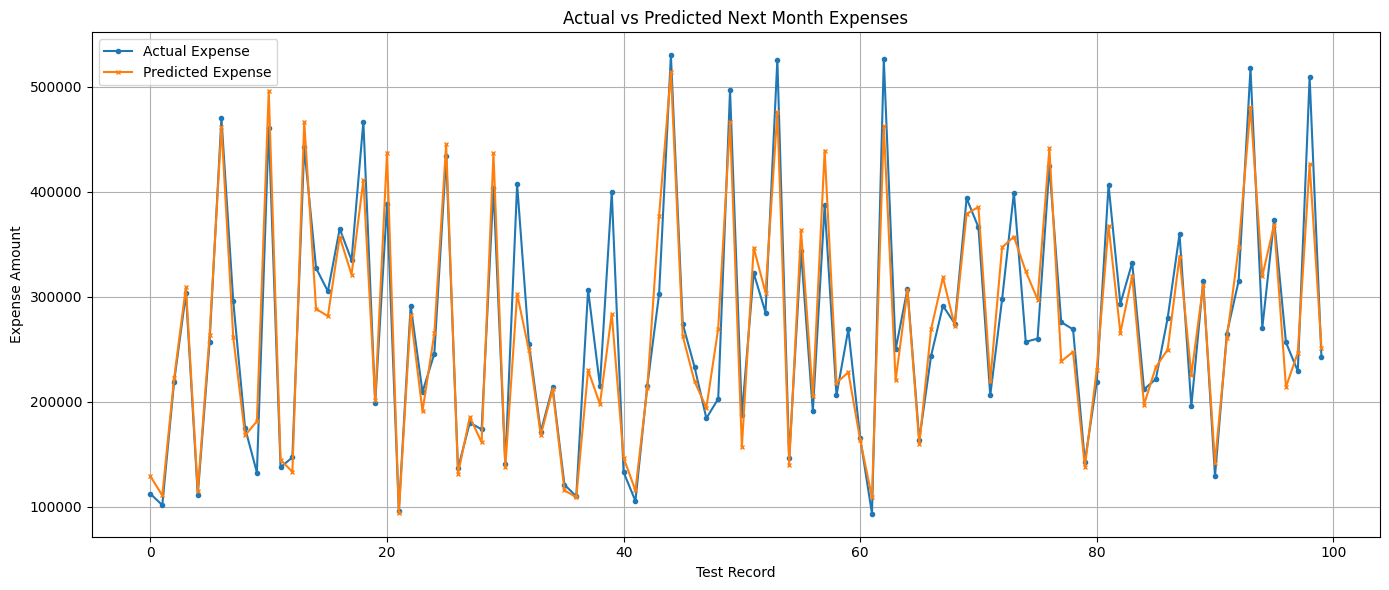

In [23]:
sample_size = min(100, len(prediction_results))

plt.figure(figsize=(14, 6))

plt.plot(
    range(sample_size),
    prediction_results["ActualNextMonthExpense"].iloc[:sample_size],
    label="Actual Expense",
    marker="o",
    markersize=3
)

plt.plot(
    range(sample_size),
    prediction_results["PredictedNextMonthExpense"].iloc[:sample_size],
    label="Predicted Expense",
    marker="x",
    markersize=3
)

plt.title("Actual vs Predicted Next Month Expenses")
plt.xlabel("Test Record")
plt.ylabel("Expense Amount")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

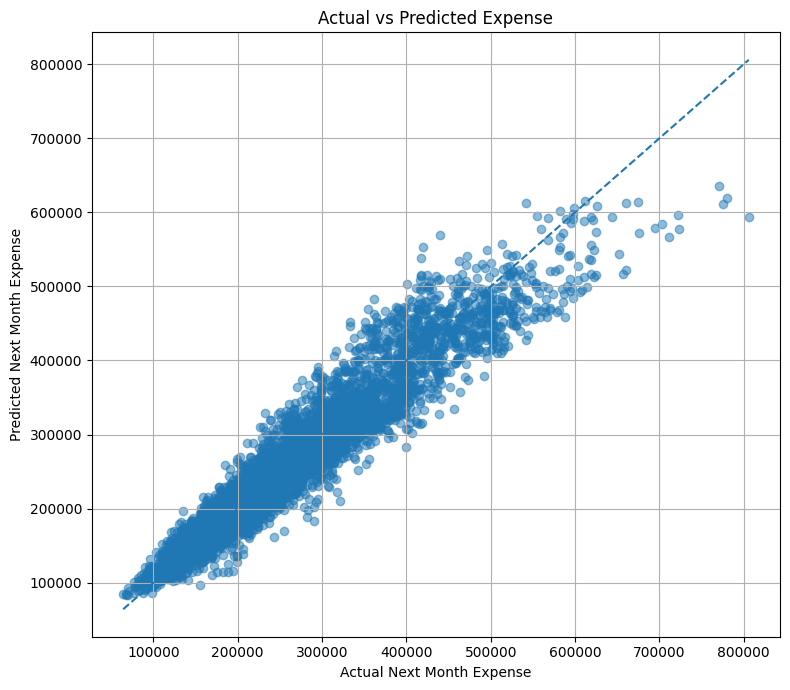

In [24]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Expense")
plt.xlabel("Actual Next Month Expense")
plt.ylabel("Predicted Next Month Expense")
plt.grid(True)
plt.tight_layout()
plt.show()

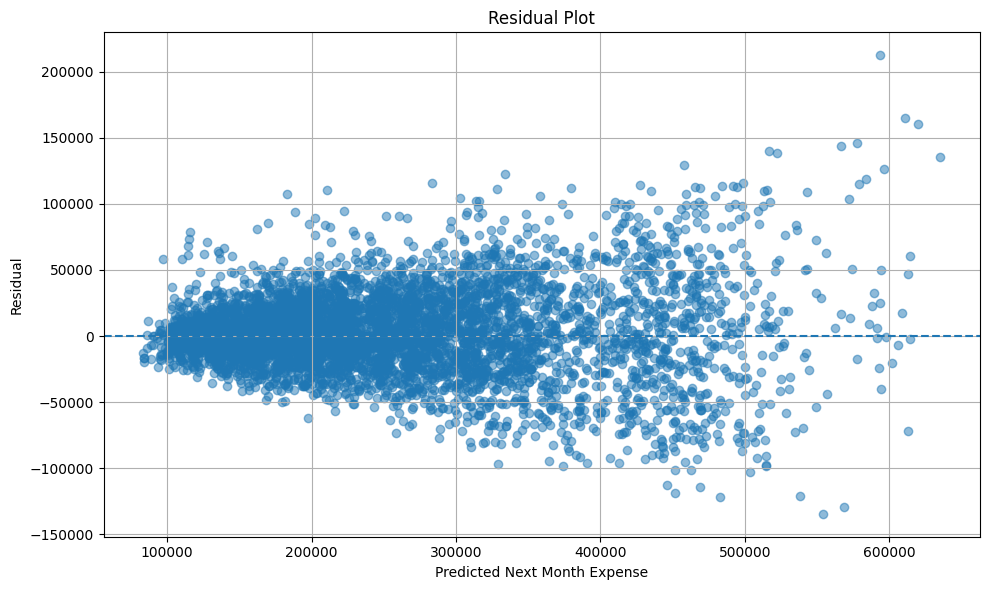

In [25]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Next Month Expense")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,MonthlyIncome,24.242869
1,PreviousMonthExpense,16.698986
2,Investment,12.719516
3,TotalExpense,12.490263
4,FamilySize,7.443955
5,Savings,4.691519
6,Rent,4.323819
7,Groceries,3.728693
8,Occupation,2.147595
9,Utilities,1.486656


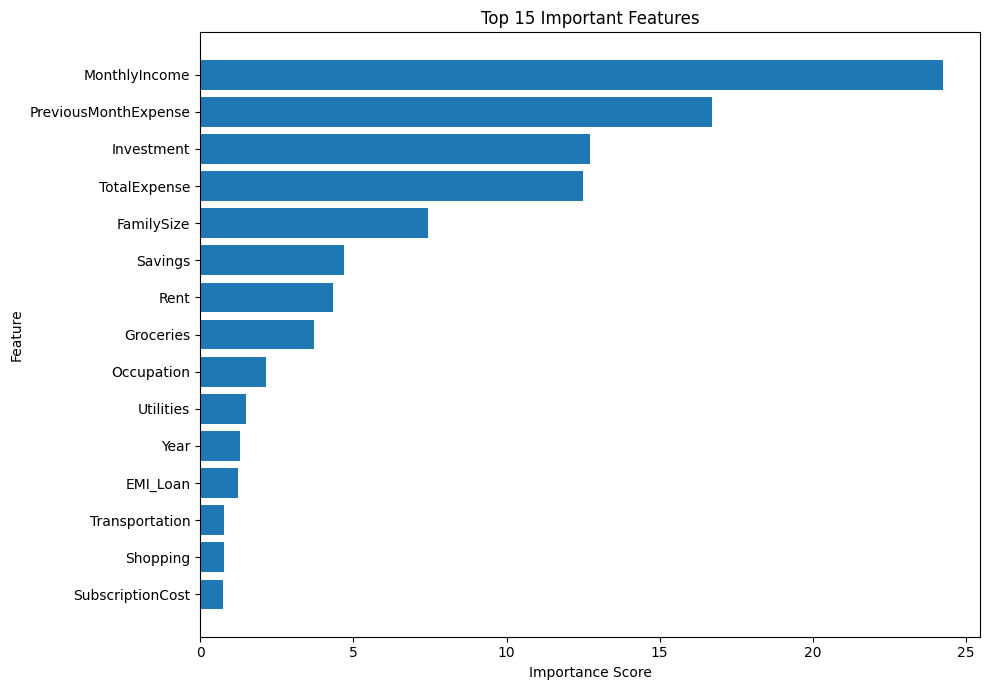

In [27]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
prediction_results.to_csv(
    "catboost_prediction_results.csv",
    index=False
)

feature_importance.to_csv(
    "catboost_feature_importance.csv",
    index=False
)

print("Prediction results saved.")
print("Feature importance saved.")

Prediction results saved.
Feature importance saved.


In [29]:
model.save_model(
    "expense_prediction_catboost.cbm"
)

print(
    "CatBoost model saved as "
    "'expense_prediction_catboost.cbm'"
)

CatBoost model saved as 'expense_prediction_catboost.cbm'


In [30]:
model_metadata = {
    "model_name": "CatBoost Next Month Expense Prediction Model",
    "target_column": target_column,
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "month_mapping": month_mapping,
    "evaluation": {
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2),
        "MAPE": float(mape)
    }
}

with open(
    "expense_model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4
    )

print("Model metadata saved.")

Model metadata saved.


In [31]:
def prepare_input_data(expense_details: dict) -> pd.DataFrame:
    """
    Convert one user's current-month expense details
    into the format expected by the trained model.
    """

    input_data = expense_details.copy()

    required_original_fields = [
        "UserID",
        "Year",
        "Month",
        "Age",
        "Occupation",
        "FamilySize",
        "CityType",
        "MonthlyIncome",
        "Rent",
        "Groceries",
        "Transportation",
        "Utilities",
        "Healthcare",
        "Education",
        "Entertainment",
        "Shopping",
        "SubscriptionCount",
        "SubscriptionCost",
        "EMI_Loan",
        "Investment",
        "Savings",
        "PreviousMonthExpense",
        "FestivalMonth",
        "TotalExpense"
    ]

    missing_fields = [
        field
        for field in required_original_fields
        if field not in input_data
    ]

    if missing_fields:
        raise ValueError(
            f"Missing required input fields: {missing_fields}"
        )

    month_name = str(input_data["Month"]).strip()

    if month_name not in month_mapping:
        raise ValueError(
            f"Invalid month name: {month_name}"
        )

    month_number = month_mapping[month_name]

    input_data["MonthNumber"] = month_number

    input_data["MonthSin"] = np.sin(
        2 * np.pi * month_number / 12
    )

    input_data["MonthCos"] = np.cos(
        2 * np.pi * month_number / 12
    )

    prepared_df = pd.DataFrame([input_data])

    prepared_df = prepared_df[feature_columns]

    for column in categorical_features:
        prepared_df[column] = (
            prepared_df[column]
            .fillna("Unknown")
            .astype(str)
        )

    for column in numeric_features:
        prepared_df[column] = pd.to_numeric(
            prepared_df[column],
            errors="coerce"
        )

        if prepared_df[column].isnull().any():
            raise ValueError(
                f"Invalid numeric value provided for {column}"
            )

    return prepared_df


def predict_next_month_expense(expense_details: dict) -> float:
    """
    Predict the overall expense for the next month.
    """

    prepared_data = prepare_input_data(expense_details)

    prediction = model.predict(prepared_data)[0]

    # Prevent an impossible negative expense prediction
    prediction = max(0, float(prediction))

    return round(prediction, 2)

In [32]:
sample_expense = {
    "UserID": "U0501",
    "Year": 2025,
    "Month": "December",
    "Age": 30,
    "Occupation": "Engineer",
    "FamilySize": 4,
    "CityType": "Urban",
    "MonthlyIncome": 150000.00,
    "Rent": 30000.00,
    "Groceries": 22000.00,
    "Transportation": 12000.00,
    "Utilities": 8000.00,
    "Healthcare": 5000.00,
    "Education": 10000.00,
    "Entertainment": 6000.00,
    "Shopping": 9000.00,
    "SubscriptionCount": 4,
    "SubscriptionCost": 3500,
    "EMI_Loan": 15000.00,
    "Investment": 10000.00,
    "Savings": 12000.00,
    "PreviousMonthExpense": 110000.00,
    "FestivalMonth": 1,
    "TotalExpense": 120500.00
}

predicted_expense = predict_next_month_expense(
    sample_expense
)

print("=" * 50)
print("NEXT MONTH EXPENSE PREDICTION")
print("=" * 50)
print(f"Current Month Expense : Rs. {sample_expense['TotalExpense']:,.2f}")
print(f"Predicted Next Month  : Rs. {predicted_expense:,.2f}")

NEXT MONTH EXPENSE PREDICTION
Current Month Expense : Rs. 120,500.00
Predicted Next Month  : Rs. 165,540.26
